### This example demostrates how to use GeoShapley to explain the spatial effects in a machine learning model.

The difference between GeoShapley and SHAP is that GeoShapley is able to tease out any effects that are associated with location by looking at how location and another feature collectively contribute to the prediction "game".

In [1]:
#pip install geoshapley

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Data

In [3]:
houses = pd.read_csv("https://raw.githubusercontent.com/Ziqi-Li/GIS5122/spring-25/data/seattle_sample_1k.csv")

In [4]:
houses.head()

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price
0,0,3.00,2660,4600,8,3,0,0,109,552217.557035,5.274945e+06,6.091315
1,1,2.25,2530,8736,7,4,0,0,57,565692.484331,5.272758e+06,5.790988
2,2,2.00,1390,13464,7,4,0,0,28,562451.661509,5.245291e+06,5.315130
3,3,1.00,940,4264,7,5,0,0,66,546816.935618,5.264407e+06,5.619093
4,4,2.25,2070,7225,8,3,0,0,36,564343.195352,5.244978e+06,5.477121


In [5]:
#Usually we want to log the skewed variable for the model to easier be optimized
#But here I reverted it back to dollar value for simpler interpretation.
y = 10**houses.log_price/1000

X = houses[['bathrooms', 'sqft_living', 'sqft_lot', 'grade',
       'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]

In [6]:
X.describe()

,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2.040500,1954.711000,7437.067000,7.508000,3.470000,0.008000,0.219000,49.094000,555090.973162,5.269253e+06
std,0.771739,795.175658,3541.230107,1.083102,0.695402,0.089129,0.737281,29.047563,6811.126645,1.504789e+04
min,0.750000,580.000000,651.000000,5.000000,1.000000,0.000000,0.000000,0.000000,542351.561206,5.234196e+06
25%,1.500000,1380.000000,5000.000000,7.000000,3.000000,0.000000,0.000000,25.000000,549352.543915,5.259722e+06
50%,2.000000,1800.000000,7350.000000,7.000000,3.000000,0.000000,0.000000,50.000000,553361.945522,5.270805e+06
75%,2.500000,2382.500000,9376.250000,8.000000,4.000000,0.000000,0.000000,67.000000,561191.194563,5.281673e+06
max,5.250000,5540.000000,19991.000000,12.000000,5.000000,1.000000,4.000000,115.000000,569768.086080,5.291748e+06


We can split the data into training (80%) and testing (20%). The model will be trained based on the training data and the testing data will be used to evaluate the model accuracy on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## AutoML to tune an XGBoost model

In [8]:
from flaml import AutoML


settings = {
    "time_budget": 20,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": ['xgboost'],  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5 #5-fold cross validation
}

automl = AutoML()
automl.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 04-02 09:33:34] {1728} INFO - task = regression
[flaml.automl.logger: 04-02 09:33:34] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 04-02 09:33:34] {1838} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 04-02 09:33:34] {1955} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 04-02 09:33:34] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 04-02 09:33:34] {2393} INFO - Estimated sufficient time budget=356s. Estimated necessary time budget=0s.
[flaml.automl.logger: 04-02 09:33:34] {2442} INFO -  at 0.0s,	estimator xgboost's best error=0.7035,	best estimator xgboost's best error=0.7035
[flaml.automl.logger: 04-02 09:33:34] {2258} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 04-02 09:33:34] {2442} INFO -  at 0.1s,	estimator xgboost's best error=0.7035,	best estimator xgboost's best error=0.7035
[flaml.automl.logger: 04-02 09:33:34] {2258} INFO - iteration 2, current learner x

### XGBoost

In [9]:
xgb_pred = automl.predict(X_test)

In [10]:
from sklearn.metrics import r2_score
r2_score(y_test, xgb_pred)

0.8276298230309305

The model has an R2 value of 0.827 for the test data.

### GeoShapley explanations

In [11]:
#Installation
#pip install shap

In [12]:
import geoshapley

In [13]:
best_xgb = automl.model.estimator

In GeoShapley, we need to specify a background dataset. The background dataset is used to average out the "missing" feature when generating the combinations. The background dataset can be the entire data or a random subset of the data. The more the better, but will be slower if the background data is too large.

In [14]:
background = X.sample(100) # Here we use 100 random samples as the background.


In [15]:
# Initialize the GeoShapleyExplainer with the best trained XGBoost model
explainer = geoshapley.GeoShapleyExplainer(best_xgb.predict, background.values)

# Compute SHAP values for the entire dataset. You can also just compute for the test dataset.
geo_shap_values = explainer.explain(X)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [17]:
total_geoshapley = geo_shap_values.primary.sum(axis=1) + geo_shap_values.geo + \
                   geo_shap_values.geo_intera.sum(axis=1) + geo_shap_values.base_value

Remember the predicted value is a sum of a base_value and Shap value for each feature.

y_pred = base_value + geo + Σj primary + Σj geo_intera

Below we prove this:

In [18]:
#Left hand side
total_y_pred = best_xgb.predict(X)

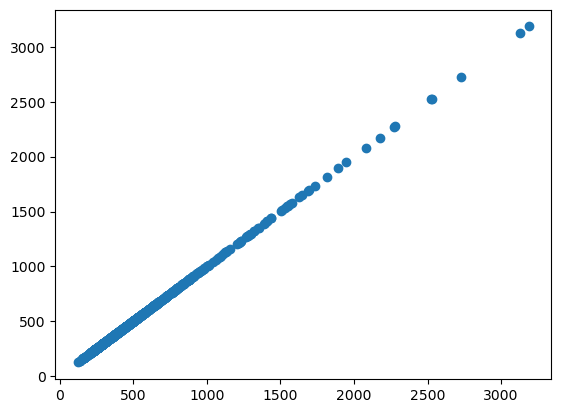

In [19]:
plt.scatter(total_y_pred, total_geoshapley)

There is also a convenient function to check.

In [20]:
geo_shap_values.check_additivity()

Components add up to model prediction:  True


### GeoShapley results

Similar to SHAP, GeoSHapley can give you a SHAP-style summary plot that ranks feature importance from top to bottom. GEO refers to location effect, and GEO X another feature refers to their collective effect.

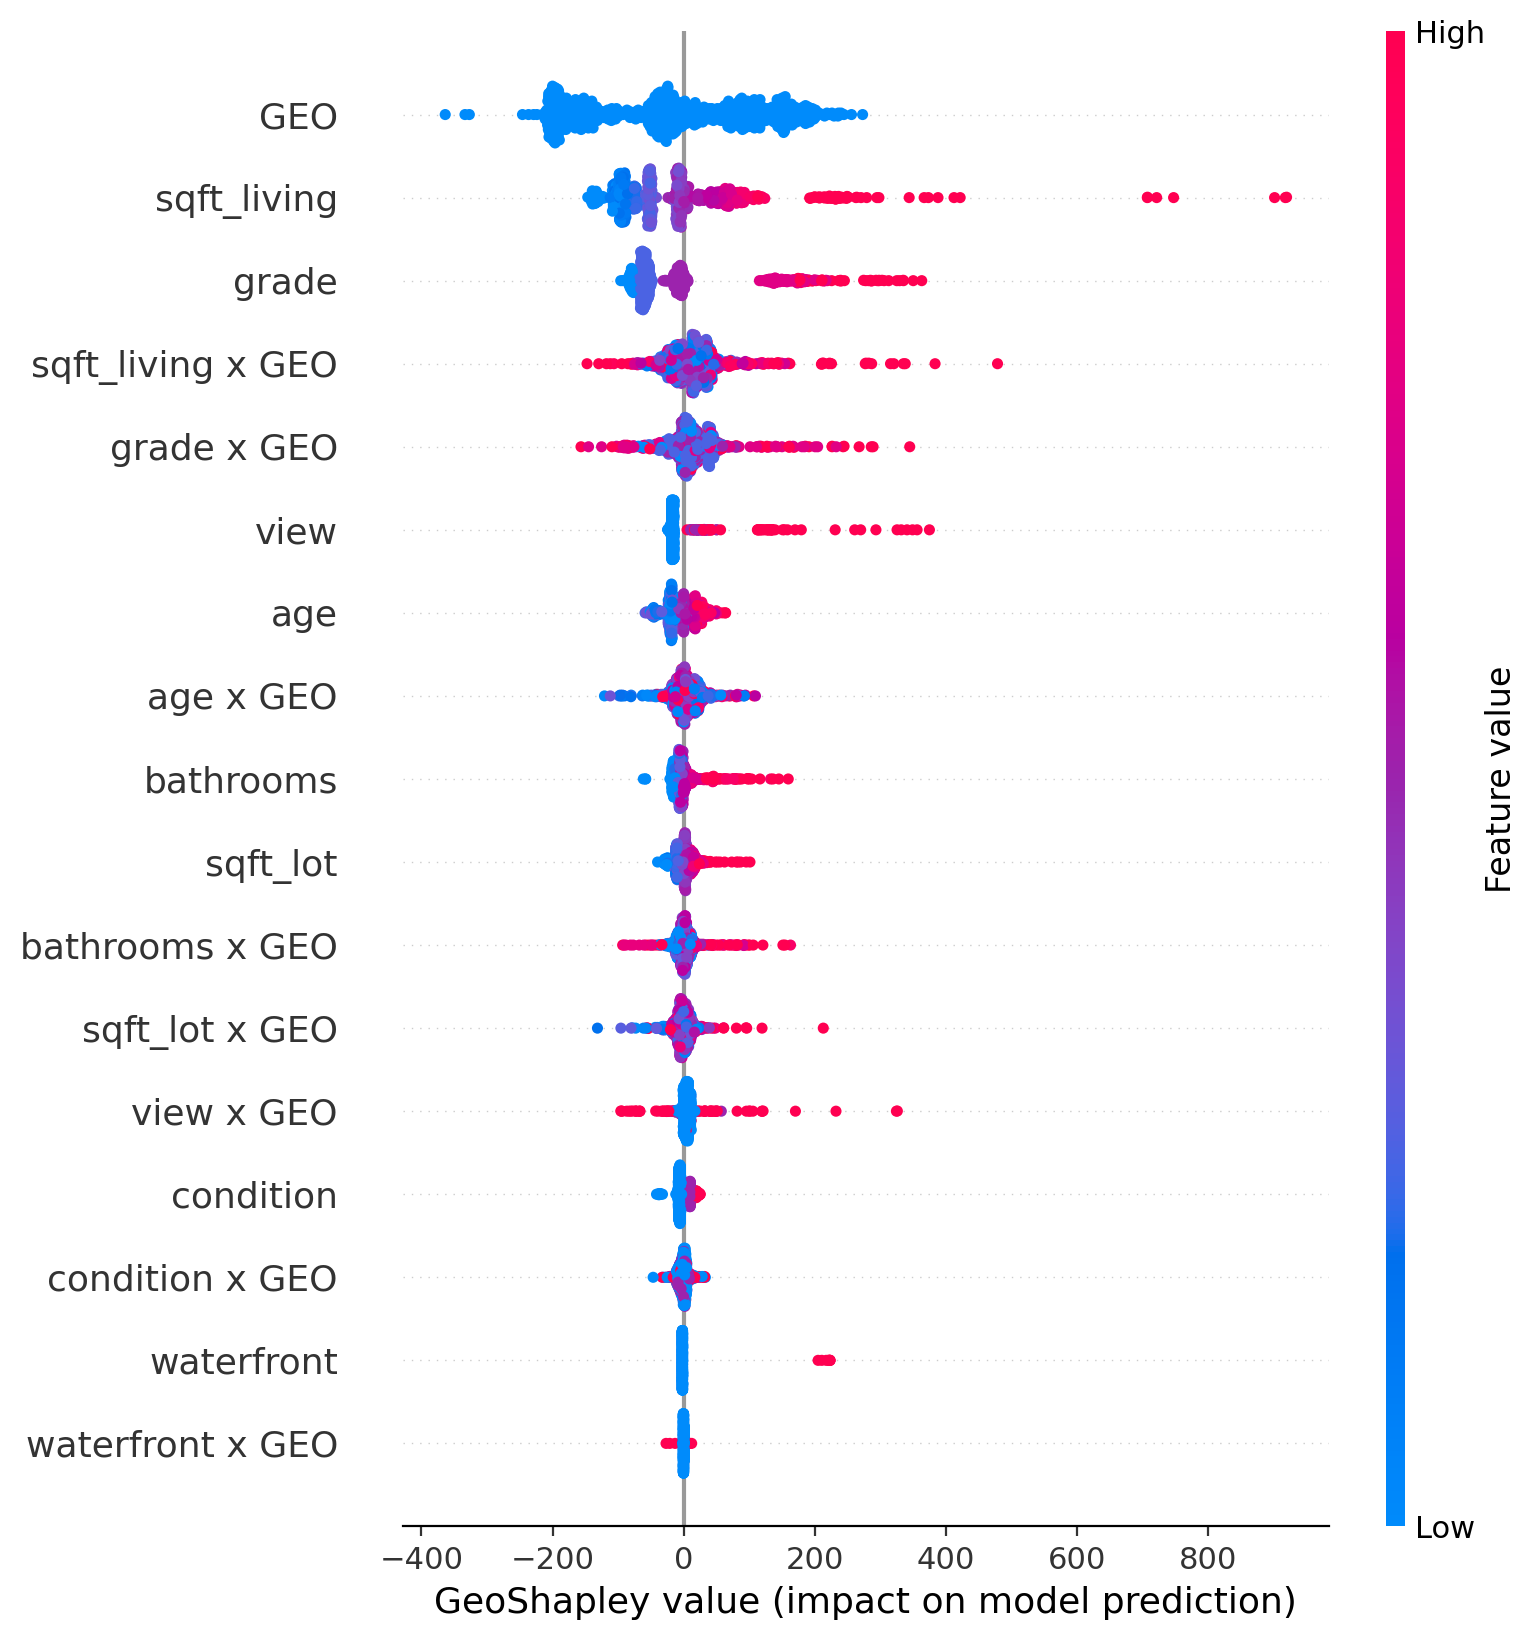

In [21]:
geo_shap_values.summary_plot()

GeoShapley has a convenient function to plot partitial dependence plots.

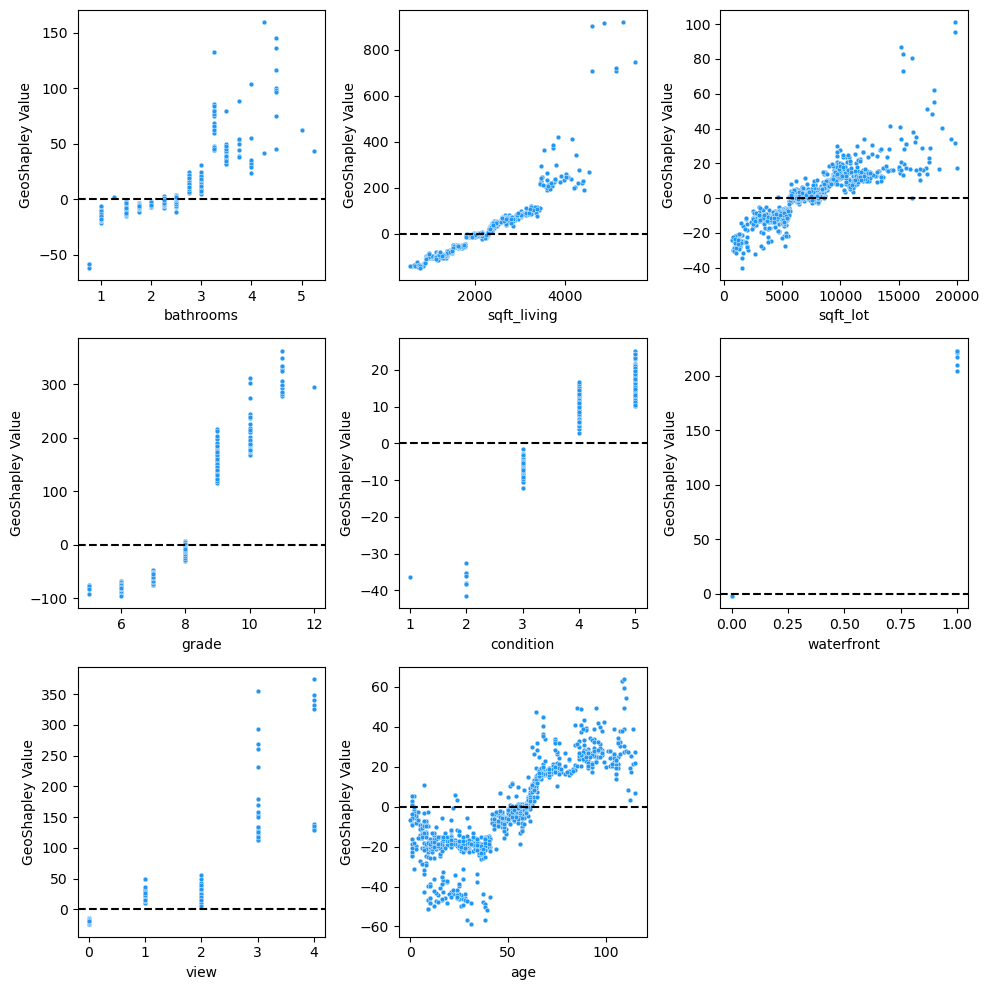

In [22]:
geo_shap_values.partial_dependence_plots(figsize=(10,10))

It can also do a GAM style curve fitting for each partitial dependence plot to show the overall trend/relationship.

100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (5 of 5) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00


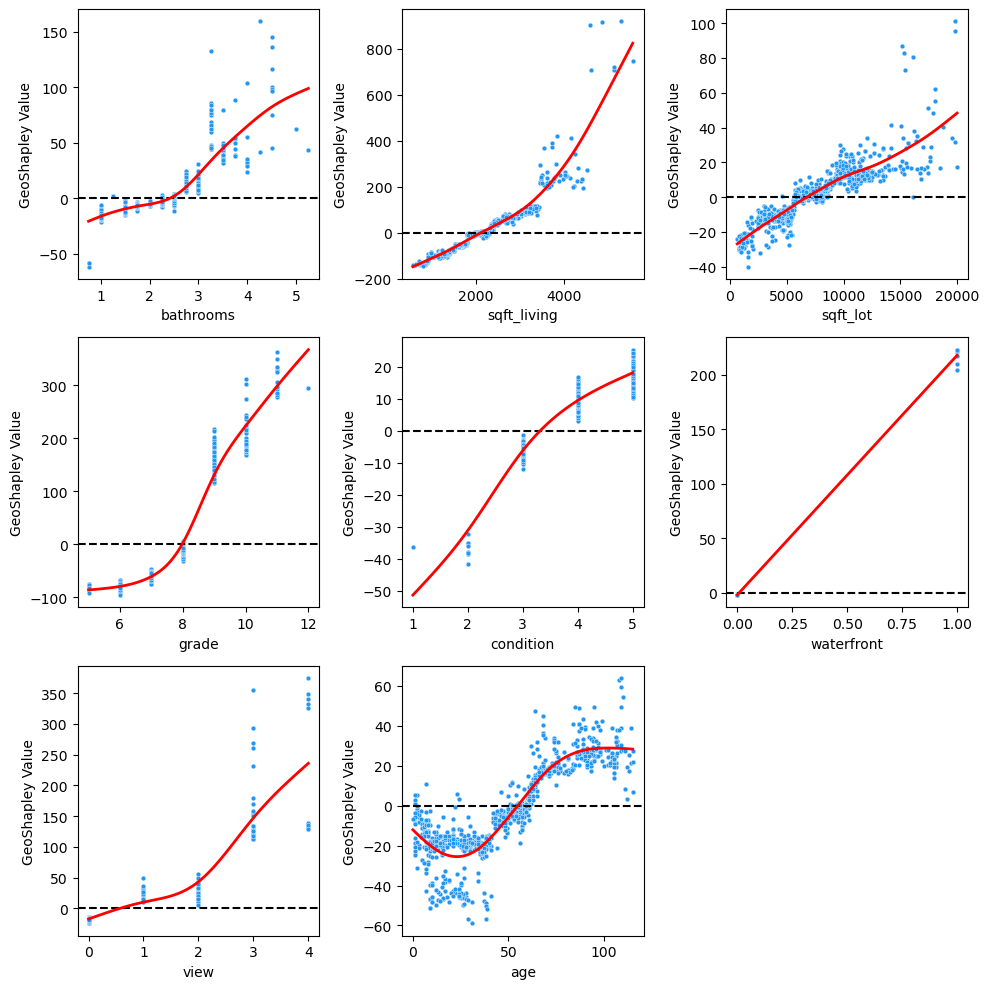

In [23]:
geo_shap_values.partial_dependence_plots(figsize=(10,10),gam_curve=True)

## Spatial effects

Next we can look at location effects.

First let's look at location value for each house while holding the house characrists the same. Remember the unit of the scale bar is 1,000 US Dollars. We can see downtown and Bellevue has intriict location values around 700,000 dollars, sort of like the value of the land. The southern suburb areas have low land value and can be as low as 200,000 USD dollars.

In [24]:
base_location_values = geo_shap_values.base_value + geo_shap_values.geo

In [25]:
import geopandas as gpd
import contextily as cx

sea_map = gpd.GeoDataFrame(
    X, crs="EPSG:32610", geometry=gpd.points_from_xy(x=X.UTM_X, y=X.UTM_Y))
#sea_map = sea_map.to_crs("EPSG:4326")

Text(0.5, 1.0, 'Location contribution ($1,000)')

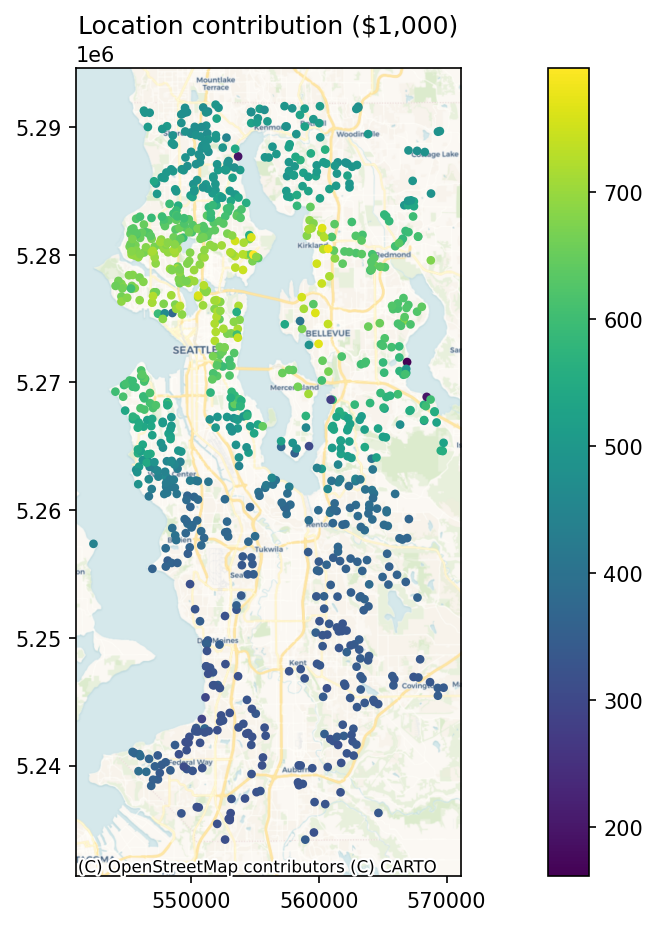

In [26]:
fig, ax = plt.subplots(1, 1,figsize=(15,7),dpi=150)

sea_map.plot(ax=ax, column=base_location_values,legend=True,s=10)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs=sea_map.crs,zoom=11)
plt.title("Location contribution ($1,000)")

WE can also generate maps to examine spatially varying relationships for features that have stronger interaction with location. From the summary plot we see sqft_living and grade are interacting with location.

To calculate spatially varying coefficients, anologous to GWR, we need to do this for the columns of interest


In [27]:
X.columns

Index(['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition',
       'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y'],
      dtype='object')

In [28]:
svcs = geo_shap_values.get_svc([1, 3],coef_type='gwr',include_primary=True)

Text(0.5, 1.0, 'sqft_living X location')

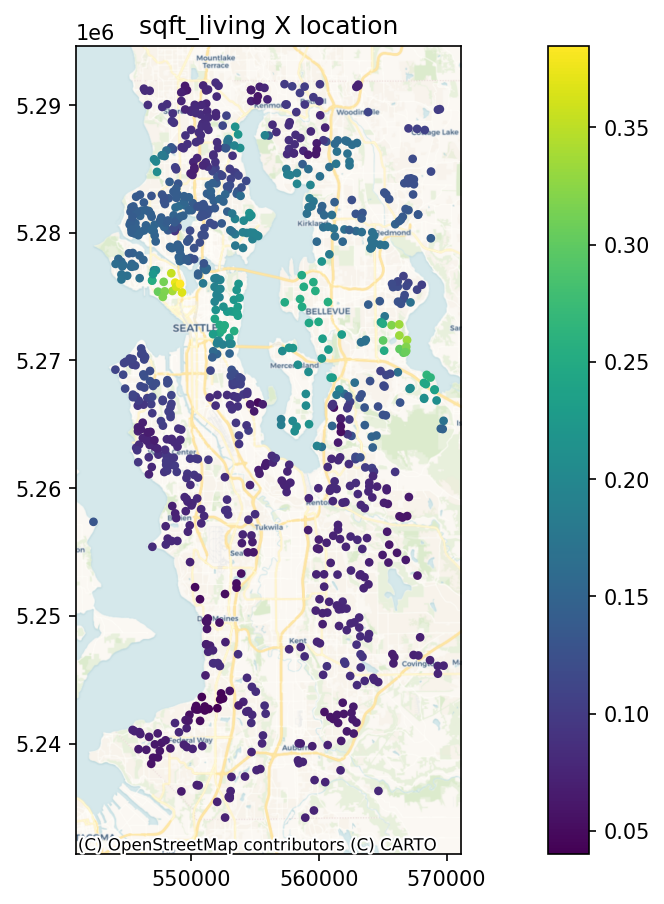

In [29]:
fig, ax = plt.subplots(1, 1,figsize=(15,7),dpi=150)

sea_map.plot(ax=ax, column=svcs[:,0],legend=True,s=10)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs=sea_map.crs,zoom=11)

plt.title("sqft_living X location")

Text(0.5, 1.0, 'sqft_living X grade')

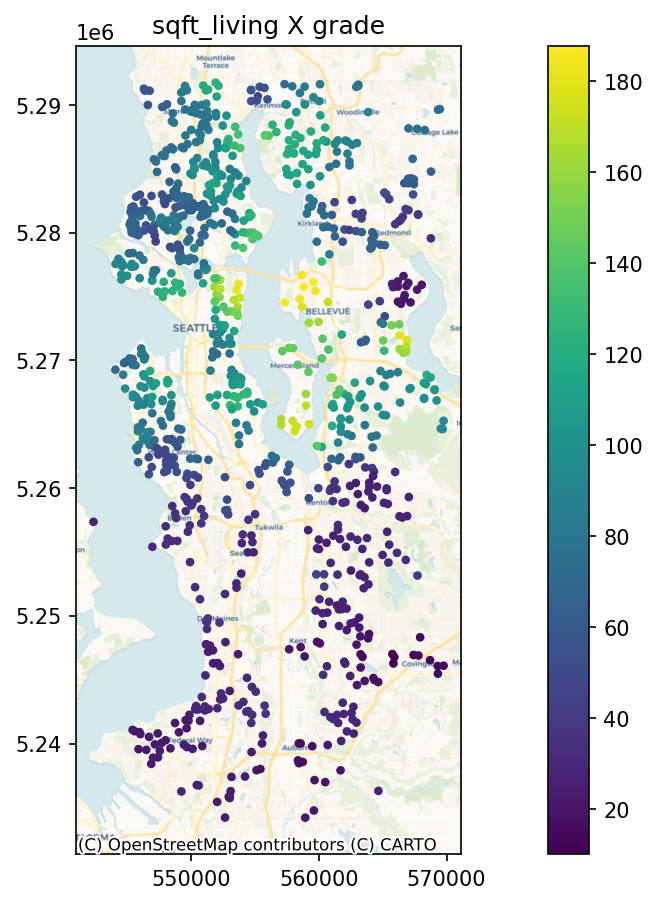

In [30]:
fig, ax = plt.subplots(1, 1,figsize=(15,7),dpi=150)

sea_map.plot(ax=ax, column=svcs[:,1],legend=True,s=10)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs=sea_map.crs,zoom=11)

plt.title("sqft_living X grade")

Both show some spatially varying effects when increasing sqft_living or grade of the property will increase the house price by a certain amouont.